In [ ]:
! pip install opendatasets


In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

In [3]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/gorororororo23/laliga-team-logos-dataset-for-cnn")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: yasir90
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/gorororororo23/laliga-team-logos-dataset-for-cnn


100%|██████████| 29.9M/29.9M [00:00<00:00, 578MB/s]

In [4]:
train_dir = "/content/laliga-team-logos-dataset-for-cnn/Laliga teams"

In [5]:
import os
print(os.listdir("/content"))

['.config', 'laliga-team-logos-dataset-for-cnn', 'sample_data']


In [6]:
import os
print(os.listdir("/content/laliga-team-logos-dataset-for-cnn"))

['Laliga teams']


In [7]:
import os
print(os.listdir("/content/laliga-team-logos-dataset-for-cnn/Laliga teams"))

['Atletico Madrid', 'Barcelona', 'Mallorca', 'Valencia', 'Las Palmas', 'Deportivo Alaves', 'Real Madrid', 'Sevilla', 'Girona', 'Villarreal', 'Espanyol', 'Real Sociedad', 'Leganes', 'Rayo Vallecano', 'Real Valladolid', 'Celta Vigo', 'Real Betis', 'Osasuna', 'Getafe', 'Athletic Bilbao']


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step


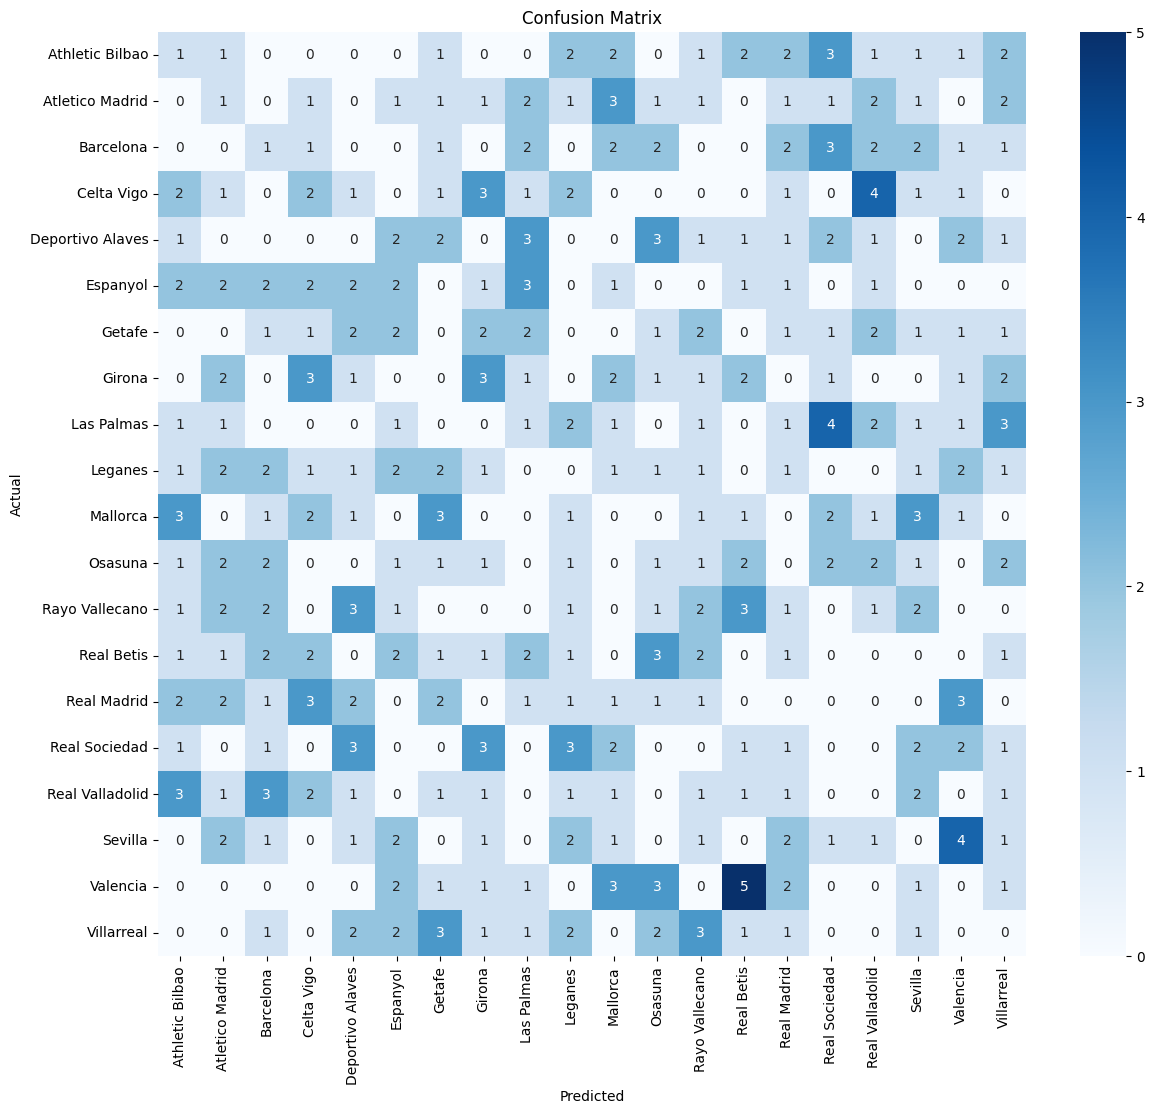

In [20]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions
val_generator.reset()
pred = model.predict(val_generator)
pred_classes = np.argmax(pred, axis=1)

true_classes = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(14,12))
sns.heatmap(
    cm,
    xticklabels=class_labels,
    yticklabels=class_labels,
    annot=True,        # 🔥 Value দেখাবে
    fmt='d',           # Integer format
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

In [9]:
import os

train_dir = "/content/laliga-team-logos-dataset-for-cnn/Laliga teams"

class_counts = {}

for team in os.listdir(train_dir):
    team_path = os.path.join(train_dir, team)
    class_counts[team] = len(os.listdir(team_path))

print(class_counts)

{'Atletico Madrid': 100, 'Barcelona': 100, 'Mallorca': 100, 'Valencia': 100, 'Las Palmas': 100, 'Deportivo Alaves': 100, 'Real Madrid': 100, 'Sevilla': 100, 'Girona': 100, 'Villarreal': 100, 'Espanyol': 100, 'Real Sociedad': 100, 'Leganes': 100, 'Rayo Vallecano': 100, 'Real Valladolid': 100, 'Celta Vigo': 100, 'Real Betis': 100, 'Osasuna': 100, 'Getafe': 100, 'Athletic Bilbao': 100}


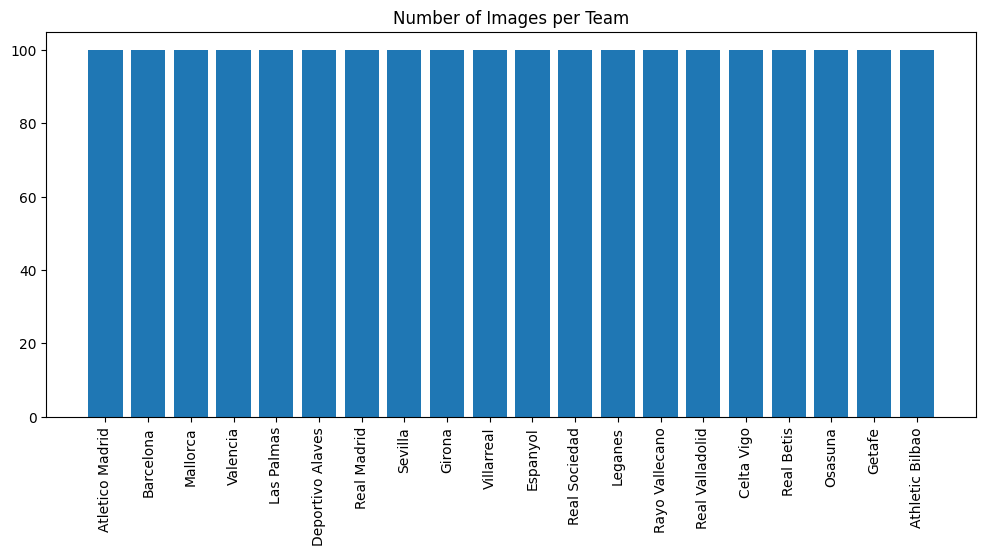

In [10]:
import matplotlib.pyplot as plt

teams = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(12,5))
plt.bar(teams, counts)
plt.xticks(rotation=90)
plt.title("Number of Images per Team")
plt.show()

In [11]:
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    subset="training"
)

val_generator = datagen.flow_from_directory(
    train_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    subset="validation"
)

num_classes = len(train_generator.class_indices)
print("Total Classes:", num_classes)

Found 1600 images belonging to 20 classes.
Found 400 images belonging to 20 classes.
Total Classes: 20


In [12]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,521,172 (24.88 MB)

 Trainable params: 6,521,172 (24.88 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 282ms/step - accuracy: 0.1323 - loss: 2.8377 - val_accuracy: 0.6550 - val_loss: 1.2885
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 190ms/step - accuracy: 0.5159 - loss: 1.4517 - val_accuracy: 0.9000 - val_loss: 0.3982
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - accuracy: 0.7862 - loss: 0.6479 - val_accuracy: 0.9525 - val_loss: 0.1657
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 13s 263ms/step - accuracy: 0.8764 - loss: 0.3684 - val_accuracy: 0.9975 - val_loss: 0.0369
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 194ms/step - accuracy: 0.9398 - loss: 0.1983 - val_accuracy: 0.9975 - val_loss: 0.0269
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 242ms/step - accuracy: 0.9391 - loss: 0.1742 - val_accuracy: 0.9950 - val_loss: 0.0316
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 194ms/step - accuracy: 0.9433 - loss: 0.1506 - val_accuracy: 0.9850 - val_loss: 0.0452
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 176ms/step - accuracy: 0.9510 - loss: 0.1515 - val_accura

In [15]:
test_loss, test_acc = model.evaluate(val_generator)
print("Validation (Realistic) Accuracy:", test_acc)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 129ms/step - accuracy: 1.0000 - loss: 7.6286e-04
Validation (Realistic) Accuracy: 1.0


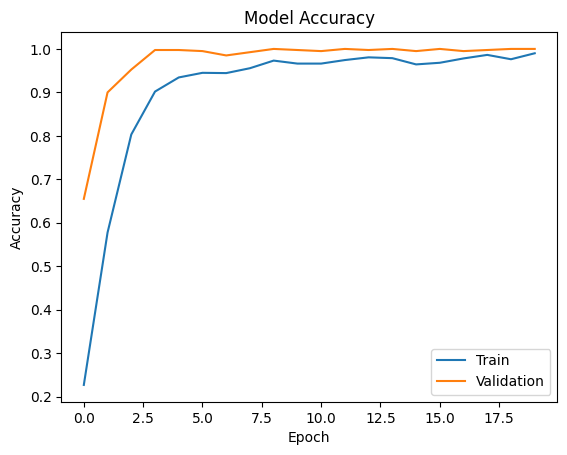

In [16]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train", "Validation"])
plt.show()

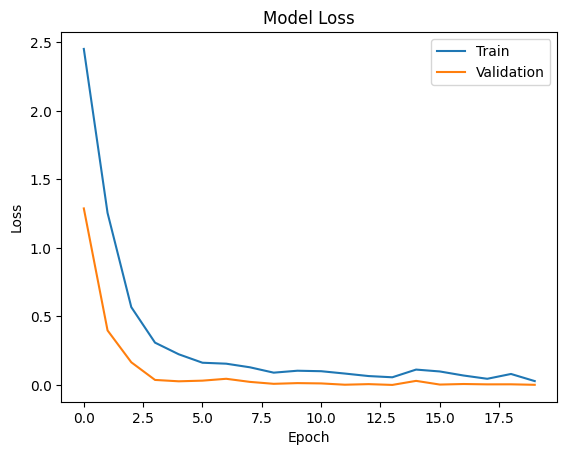

In [17]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [18]:
model.save("laliga_logo_model.h5")

In [19]:
import numpy as np
from tensorflow.keras.preprocessing import image


img_path = "/content/laliga-team-logos-dataset-for-cnn/Laliga teams/Real Madrid/img77.jpg"

# Load image
img = image.load_img(img_path, target_size=(128,128))

# Convert to array
img_array = image.img_to_array(img)

# Normalize
img_array = img_array / 255.0

# Expand dimension
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)

# Class names
class_names = list(train_generator.class_indices.keys())

predicted_index = np.argmax(prediction)
confidence = np.max(prediction)

print("Predicted Team:", class_names[predicted_index])
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 666ms/step
Predicted Team: Real Madrid
Confidence: 0.99999046


In [21]:
import json

with open("class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)

In [22]:
from google.colab import files
files.download("class_indices.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>